# Hand Sign Predictor — Standalone Weeks 1–3 Notebook

This notebook is designed to be **self-contained in code** (no imports from `src/` required).

It includes:
- Week 1 classical baseline (SVM + Random Forest) with confusion matrix
- Week 2 MLP neural experiment with optional W&B logging
- Week 3 inference utilities and Streamlit app launcher helper
- In-notebook display of existing report metrics and figures

## Important submission note
This notebook is currently configured to **show results from previously trained models and previously generated report artifacts**.
- Current default: `RUN_TRAINING = False`
- This means the notebook reads existing outputs from `models/`, `reports/metrics/`, and `reports/figures/`.
- This is intentional for reproducible grading and fast review.

### Cell 2 — Optional environment setup
Use this cell only if your environment is missing required packages. If everything imports correctly, you can leave it commented out.

In [29]:
# Run once if needed:
# %pip install -r requirements.txt

### Cell 3 — Import dependencies
Loads all libraries used across Weeks 1–3 (classical ML, PyTorch, plotting, image processing, and file I/O).

In [30]:
import json
import shlex
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image, ImageOps
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

### Cell 4 — Configure paths and run mode
Defines dataset/model/report directories and toggles:
- `RUN_TRAINING=False` reuses existing artifacts
- `RUN_TRAINING=True` retrains models and regenerates outputs

In [31]:
def find_project_root(start: Path) -> Path:
    markers = ["requirements.txt", "src", "data_and_test_models", "reports"]

    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate

    raise FileNotFoundError(
        "Could not locate project root. Make sure notebook is inside Hand-Sign-Predictor "
        "or set ROOT manually."
    )

ROOT = find_project_root(Path.cwd())

TRAIN_CSV = ROOT / 'data_and_test_models' / 'Data' / 'sign_mnist_train.csv'
TEST_CSV = ROOT / 'data_and_test_models' / 'Data' / 'sign_mnist_test.csv'

MODELS_CLASSICAL = ROOT / 'models' / 'classical'
MODELS_NEURAL = ROOT / 'models' / 'neural'
METRICS_DIR = ROOT / 'reports' / 'metrics'
FIGURES_DIR = ROOT / 'reports' / 'figures'

for folder in [MODELS_CLASSICAL, MODELS_NEURAL, METRICS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TRAINING = False
USE_WANDB = False

print('Project root:', ROOT)
print('Train CSV exists:', TRAIN_CSV.exists())
print('Test CSV exists:', TEST_CSV.exists())
print('RUN_TRAINING:', RUN_TRAINING)

Project root: /Users/jasem/Library/CloudStorage/OneDrive-UniversityofLouisianaMonroe/Hand sign predicter/Hand-Sign-Predictor
Train CSV exists: True
Test CSV exists: True
RUN_TRAINING: False


### Cell 5 — Core data/model definitions
Implements notebook-local equivalents of project modules:
- label mapping
- CSV loader and normalization
- `SignMLP` architecture
This keeps the notebook self-contained.

In [32]:
LABEL_TO_LETTER: Dict[int, str] = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I',
    10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R',
    18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'
}

def get_sorted_labels() -> List[int]:
    return sorted(LABEL_TO_LETTER.keys())

def label_to_letter(label: int) -> str:
    return LABEL_TO_LETTER.get(label, str(label))

@dataclass
class DatasetSplit:
    x: np.ndarray
    y: np.ndarray

def load_sign_mnist_csv(csv_path: Path, normalize: bool = True) -> DatasetSplit:
    df = pd.read_csv(csv_path)
    if 'label' not in df.columns:
        raise ValueError(f"Missing 'label' column in {csv_path}")

    pixel_cols = [c for c in df.columns if c != 'label']
    df[pixel_cols] = df[pixel_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

    y = pd.to_numeric(df['label'], errors='raise').to_numpy(dtype=np.int64)
    x = df[pixel_cols].to_numpy(dtype=np.float32)

    if normalize:
        x = x / 255.0
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return DatasetSplit(x=x, y=y)

class SignMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], num_classes: int, activation: str = 'relu'):
        super().__init__()
        dims = [input_dim, *hidden_dims]

        if activation == 'relu':
            act_factory = nn.ReLU
        elif activation == 'tanh':
            act_factory = nn.Tanh
        elif activation == 'gelu':
            act_factory = nn.GELU
        else:
            raise ValueError('activation must be one of: relu, tanh, gelu')

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(act_factory())
            layers.append(nn.Dropout(p=0.2))
        layers.append(nn.Linear(dims[-1], num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

### Cell 6 — Classical training/evaluation helpers
Defines reusable functions for Week 1:
- build/train SVM or Random Forest
- compute metrics
- generate and save confusion matrix

In [33]:
def run_cmd(cmd: str) -> None:
    print(f"\n$ {cmd}")
    completed = subprocess.run(shlex.split(cmd), cwd=ROOT, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.returncode != 0:
        if completed.stderr:
            print(completed.stderr)
        raise RuntimeError(f"Command failed ({completed.returncode}): {cmd}")


def build_classical_model(model_type: str = 'svm', random_state: int = 42) -> Pipeline:
    if model_type == 'svm':
        model = SVC(kernel='rbf', C=5.0, gamma='scale', probability=True, random_state=random_state)
    elif model_type == 'rf':
        model = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=random_state)
    else:
        raise ValueError('model_type must be svm or rf')
    return Pipeline([('scaler', StandardScaler()), ('model', model)])


def train_classical(train_csv: Path, test_csv: Path, model_type: str, model_out: Path, metrics_out: Path) -> dict:
    train = load_sign_mnist_csv(train_csv, normalize=True)
    test = load_sign_mnist_csv(test_csv, normalize=True)

    pipeline = build_classical_model(model_type=model_type)
    pipeline.fit(train.x, train.y)
    preds = pipeline.predict(test.x)
    acc = accuracy_score(test.y, preds)

    artifact = {'model': pipeline, 'label_to_letter': LABEL_TO_LETTER, 'config': {'model_type': model_type}}
    model_out.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(artifact, model_out)

    metrics = {'accuracy': float(acc), 'model_type': model_type, 'train_samples': int(train.x.shape[0]), 'test_samples': int(test.x.shape[0])}
    metrics_out.parent.mkdir(parents=True, exist_ok=True)
    metrics_out.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    return metrics


def evaluate_classical(model_path: Path, test_csv: Path, confusion_out: Path, metrics_out: Path) -> dict:
    artifact = joblib.load(model_path)
    model = artifact['model']

    test = load_sign_mnist_csv(test_csv, normalize=True)
    preds = model.predict(test.x)

    labels = get_sorted_labels()
    letters = [label_to_letter(l) for l in labels]

    cm = confusion_matrix(test.y, preds, labels=labels)
    report = classification_report(test.y, preds, labels=labels, output_dict=True, zero_division=0)
    acc = accuracy_score(test.y, preds)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=letters, yticklabels=letters, ax=ax)
    ax.set_title('Week 1 Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()

    confusion_out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(confusion_out, dpi=200)
    plt.close(fig)

    metrics = {'accuracy': float(acc), 'labels': labels, 'letters': letters, 'classification_report': report}
    metrics_out.parent.mkdir(parents=True, exist_ok=True)
    metrics_out.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    return metrics

### Cell 7 — MLP training helper
Defines the full Week 2 neural experiment routine, including optional W&B logging and curve/image artifact export.

In [34]:
def train_mlp(
    train_csv: Path,
    test_csv: Path,
    model_out: Path,
    metrics_out: Path,
    curve_out: Path,
    *,
    epochs: int = 15,
    batch_size: int = 128,
    learning_rate: float = 1e-3,
    hidden_dims: List[int] = [512, 256, 128],
    activation: str = 'gelu',
    use_wandb: bool = False,
    wandb_project: str = 'hand-sign-predictor',
) -> dict:
    train = load_sign_mnist_csv(train_csv, normalize=True)
    test = load_sign_mnist_csv(test_csv, normalize=True)

    labels = get_sorted_labels()
    label_to_idx = {label: idx for idx, label in enumerate(labels)}

    y_train_idx = torch.tensor([label_to_idx[v] for v in train.y], dtype=torch.long)
    y_test_idx = torch.tensor([label_to_idx[v] for v in test.y], dtype=torch.long)
    x_train = torch.tensor(train.x, dtype=torch.float32)
    x_test = torch.tensor(test.x, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(x_train, y_train_idx), batch_size=batch_size, shuffle=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SignMLP(input_dim=784, hidden_dims=hidden_dims, num_classes=len(labels), activation=activation).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    run = None
    if use_wandb:
        import wandb
        run = wandb.init(project=wandb_project, config={'epochs': epochs, 'batch_size': batch_size, 'learning_rate': learning_rate, 'hidden_dims': hidden_dims, 'activation': activation})

    train_losses = []
    val_losses = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = sum(batch_losses) / max(1, len(batch_losses))

        model.eval()
        with torch.no_grad():
            logits_test = model(x_test.to(device))
            val_loss = criterion(logits_test, y_test_idx.to(device)).item()
            pred_idx = logits_test.argmax(dim=1).cpu().numpy()
            val_acc = accuracy_score(y_test_idx.numpy(), pred_idx)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if run is not None:
            run.log({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, 'val_acc': val_acc})

        print(f"Epoch {epoch + 1}/{epochs} - train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    model_out.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'state_dict': model.state_dict(), 'hidden_dims': hidden_dims, 'activation': activation, 'labels': labels}, model_out)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(train_losses, label='train_loss')
    ax1.plot(val_losses, label='val_loss')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('loss')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(val_accs, color='green', linestyle='--', label='val_acc')
    ax2.set_ylabel('accuracy')
    ax2.legend(loc='upper right')
    plt.title('Week 2 MLP Training Curves')
    plt.tight_layout()

    curve_out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(curve_out, dpi=200)
    plt.close(fig)

    metrics = {
        'best_val_acc': max(val_accs) if val_accs else None,
        'final_val_acc': val_accs[-1] if val_accs else None,
        'train_loss_last': train_losses[-1] if train_losses else None,
        'val_loss_last': val_losses[-1] if val_losses else None,
        'epochs': epochs,
        'hidden_dims': hidden_dims,
        'activation': activation,
        'wandb_run_url': run.url if run is not None else None,
    }
    metrics_out.parent.mkdir(parents=True, exist_ok=True)
    metrics_out.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

    if run is not None:
        run.finish()

    return metrics

## Week 1 — Classical Baseline (Control)

## Instructor mode: retrain instead of reuse
If you want this notebook to train fresh models instead of reusing saved ones:
1. Go to the configuration cell near the top and set `RUN_TRAINING = True`.
2. (Optional) set `USE_WANDB = True` if you want new W&B logs.
3. Run notebook top-to-bottom.
4. New artifacts will be generated and then displayed by the metrics/figure cells.

Suggested outputs to verify after retraining:
- `models/classical/svm_baseline.joblib`
- `models/classical/rf_baseline.joblib`
- `models/neural/week2_mlp.pt`
- `reports/metrics/week1_svm_train_metrics.json`
- `reports/metrics/week1_rf_train_metrics.json`
- `reports/metrics/week1_eval_metrics.json`
- `reports/metrics/week2_mlp_metrics.json`
- `reports/figures/week1_confusion_matrix.png`
- `reports/figures/week2_loss_curves.png`

This step either trains/evaluates Week 1 models (when `RUN_TRAINING=True`) or points to previously generated model/metric artifacts (when `False`).

In [35]:
week1_svm_model = MODELS_CLASSICAL / 'svm_baseline.joblib'
week1_rf_model = MODELS_CLASSICAL / 'rf_baseline.joblib'
week1_svm_metrics_path = METRICS_DIR / 'week1_svm_train_metrics.json'
week1_rf_metrics_path = METRICS_DIR / 'week1_rf_train_metrics.json'
week1_eval_metrics_path = METRICS_DIR / 'week1_eval_metrics.json'
week1_cm_path = FIGURES_DIR / 'week1_confusion_matrix.png'

if RUN_TRAINING:
    svm_metrics = train_classical(TRAIN_CSV, TEST_CSV, 'svm', week1_svm_model, week1_svm_metrics_path)
    rf_metrics = train_classical(TRAIN_CSV, TEST_CSV, 'rf', week1_rf_model, week1_rf_metrics_path)
    eval_metrics = evaluate_classical(week1_svm_model, TEST_CSV, week1_cm_path, week1_eval_metrics_path)
    print('Week 1 training complete')
else:
    print('RUN_TRAINING=False -> using existing Week 1 artifacts/results')

RUN_TRAINING=False -> using existing Week 1 artifacts/results


## Week 2 — MLP Experiment (Experiment)

This step runs the MLP experiment with the configured hyperparameters or reuses saved Week 2 outputs if retraining is disabled.

In [36]:
week2_model_path = MODELS_NEURAL / 'week2_mlp.pt'
week2_metrics_path = METRICS_DIR / 'week2_mlp_metrics.json'
week2_curve_path = FIGURES_DIR / 'week2_loss_curves.png'

if RUN_TRAINING:
    week2_metrics = train_mlp(
        TRAIN_CSV,
        TEST_CSV,
        week2_model_path,
        week2_metrics_path,
        week2_curve_path,
        epochs=15,
        batch_size=128,
        learning_rate=1e-3,
        hidden_dims=[512, 256, 128],
        activation='gelu',
        use_wandb=USE_WANDB,
        wandb_project='hand-sign-predictor',
    )
    print('Week 2 training complete')
else:
    print('RUN_TRAINING=False -> using existing Week 2 artifacts/results')

RUN_TRAINING=False -> using existing Week 2 artifacts/results


## Report Results and Figures (Displayed In-Notebook)

The next cells load report artifacts from `reports/metrics` and `reports/figures`.

With default settings (`RUN_TRAINING=False`), these are **previously generated results** from earlier training runs.
If retraining is enabled, these same cells will show **newly generated results** from the current run.

In [37]:
report_metric_files = [
    METRICS_DIR / 'week1_svm_train_metrics.json',
    METRICS_DIR / 'week1_rf_train_metrics.json',
    METRICS_DIR / 'week1_eval_metrics.json',
    METRICS_DIR / 'week2_mlp_metrics.json',
]

loaded_metrics = {}
for path in report_metric_files:
    if path.exists():
        loaded_metrics[path.name] = json.loads(path.read_text(encoding='utf-8'))
    else:
        loaded_metrics[path.name] = {'missing': True}

for name, payload in loaded_metrics.items():
    print(f"\n{name}")
    print('-' * len(name))
    print(json.dumps(payload, indent=2)[:2000])


week1_svm_train_metrics.json
----------------------------
{
  "accuracy": 0.8502509760178472,
  "model_type": "svm",
  "train_samples": 27455,
  "test_samples": 7172
}

week1_rf_train_metrics.json
---------------------------
{
  "accuracy": 0.8243167875069716,
  "model_type": "rf",
  "train_samples": 27455,
  "test_samples": 7172
}

week1_eval_metrics.json
-----------------------
{
  "accuracy": 0.8502509760178472,
  "classification_report": {
    "0": {
      "precision": 0.8970189701897019,
      "recall": 1.0,
      "f1-score": 0.9457142857142857,
      "support": 331.0
    },
    "1": {
      "precision": 1.0,
      "recall": 0.9976851851851852,
      "f1-score": 0.9988412514484357,
      "support": 432.0
    },
    "2": {
      "precision": 0.9198813056379822,
      "recall": 1.0,
      "f1-score": 0.9582689335394127,
      "support": 310.0
    },
    "3": {
      "precision": 0.9722222222222222,
      "recall": 1.0,
      "f1-score": 0.9859154929577465,
      "support": 245.0
  

### Comparison summary cell
Builds a compact accuracy table and bar chart comparing Control (SVM/RF) vs Experiment (MLP), and prints the W&B URL.

,Model,Accuracy
0,SVM,0.850251
2,MLP,0.837702
1,Random Forest,0.824317


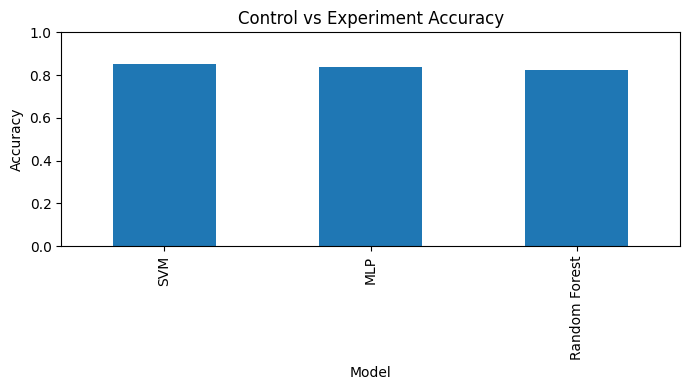

W&B URL: https://wandb.ai/cobycolvin1-/hand-sign-predictor/runs/uv7wv0cq


In [38]:
summary_rows = []

svm_acc = loaded_metrics.get('week1_svm_train_metrics.json', {}).get('accuracy')
rf_acc = loaded_metrics.get('week1_rf_train_metrics.json', {}).get('accuracy')
mlp_acc = loaded_metrics.get('week2_mlp_metrics.json', {}).get('final_val_acc')

summary_rows.append({'Model': 'SVM', 'Accuracy': svm_acc})
summary_rows.append({'Model': 'Random Forest', 'Accuracy': rf_acc})
summary_rows.append({'Model': 'MLP', 'Accuracy': mlp_acc})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('Accuracy', ascending=False, na_position='last')
display(summary_df)

plot_df = summary_df.dropna(subset=['Accuracy'])
if not plot_df.empty:
    ax = plot_df.plot(kind='bar', x='Model', y='Accuracy', legend=False, figsize=(7, 4))
    ax.set_ylim(0, 1)
    ax.set_title('Control vs Experiment Accuracy')
    ax.set_ylabel('Accuracy')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric accuracy values available to plot.')

wandb_url = loaded_metrics.get('week2_mlp_metrics.json', {}).get('wandb_run_url')
print('W&B URL:', wandb_url)

### Figure rendering cell
Displays saved `week1_confusion_matrix.png` and `week2_loss_curves.png` from your reports folder.


Figure: /Users/jasem/Library/CloudStorage/OneDrive-UniversityofLouisianaMonroe/Hand sign predicter/Hand-Sign-Predictor/reports/figures/week1_confusion_matrix.png


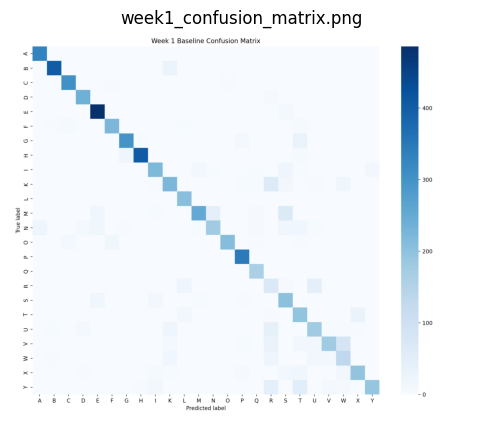


Figure: /Users/jasem/Library/CloudStorage/OneDrive-UniversityofLouisianaMonroe/Hand sign predicter/Hand-Sign-Predictor/reports/figures/week2_loss_curves.png


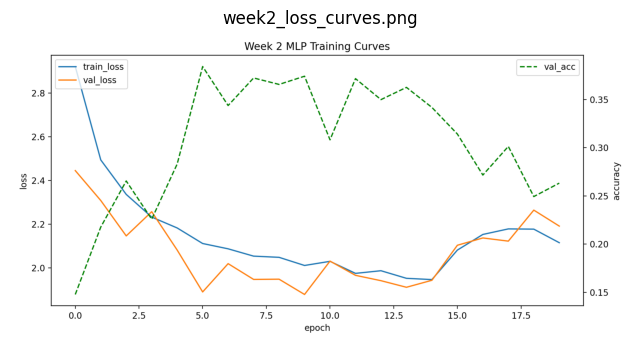

In [39]:
figure_files = [
    FIGURES_DIR / 'week1_confusion_matrix.png',
    FIGURES_DIR / 'week2_loss_curves.png',
]

for fig_path in figure_files:
    print('\nFigure:', fig_path)
    if fig_path.exists():
        img = Image.open(fig_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(fig_path.name)
        plt.show()
    else:
        print('Missing. Set RUN_TRAINING=True to regenerate.')

## Week 3 — Inference (Standalone Functions in Notebook)

### Inference utility definitions
Defines preprocessing and prediction helpers used for local single-image testing with either the classical or neural model artifacts.

In [40]:
def preprocess_uploaded_image(uploaded_image: Image.Image, auto_crop: bool = True, auto_invert: bool = True, mirror: bool = False, threshold: int = 30) -> np.ndarray:
    img = ImageOps.autocontrast(uploaded_image.convert('L'))
    arr = np.array(img, dtype=np.uint8)

    if auto_invert:
        corners = np.concatenate([arr[:5, :5].ravel(), arr[:5, -5:].ravel(), arr[-5:, :5].ravel(), arr[-5:, -5:].ravel()])
        if corners.mean() > 127:
            arr = 255 - arr

    mask = arr > int(threshold)
    if auto_crop and mask.any():
        ys, xs = np.where(mask)
        arr = arr[ys.min():ys.max()+1, xs.min():xs.max()+1]

    h, w = arr.shape
    s = max(h, w)
    padded = np.zeros((s, s), dtype=np.uint8)
    y0 = (s - h) // 2
    x0 = (s - w) // 2
    padded[y0:y0+h, x0:x0+w] = arr

    img = Image.fromarray(padded, mode='L')
    if mirror:
        img = ImageOps.mirror(img)

    try:
        resample = Image.Resampling.NEAREST
    except AttributeError:
        resample = Image.NEAREST

    img = img.resize((28, 28), resample=resample)
    return np.array(img, dtype=np.float32).reshape(1, -1) / 255.0


def predict_classical_from_path(model_path: Path, vector: np.ndarray) -> tuple[str, float]:
    artifact = joblib.load(model_path)
    model = artifact['model']
    probs = model.predict_proba(vector)[0]
    classes = model.classes_
    idx = int(np.argmax(probs))
    label = int(classes[idx])
    return label_to_letter(label), float(probs[idx])


def predict_neural_from_path(model_path: Path, vector: np.ndarray) -> tuple[str, float]:
    checkpoint = torch.load(model_path, map_location='cpu')
    model = SignMLP(
        input_dim=784,
        hidden_dims=checkpoint['hidden_dims'],
        num_classes=len(checkpoint['labels']),
        activation=checkpoint['activation'],
    )
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()

    with torch.no_grad():
        logits = model(torch.tensor(vector, dtype=torch.float32))
        probs = torch.softmax(logits, dim=1).numpy()[0]

    idx = int(np.argmax(probs))
    label = int(checkpoint['labels'][idx])
    return label_to_letter(label), float(probs[idx])

### Inference demo cell
Set `IMAGE_PATH` to an actual PNG/JPG/JPEG hand-sign image and choose model type; this cell then shows predicted letter and confidence.

In [41]:
IMAGE_PATH = ROOT / 'data_and_test_models' / 'Data' / 'sample.png'  # change to your image
PREDICT_MODEL_TYPE = 'classical'  # 'classical' or 'neural'

if not IMAGE_PATH.exists():
    print('Set IMAGE_PATH to a valid PNG/JPG/JPEG for local inference demo.')
else:
    image = Image.open(IMAGE_PATH)
    vector = preprocess_uploaded_image(image)

    if PREDICT_MODEL_TYPE == 'classical':
        pred_letter, pred_conf = predict_classical_from_path(week1_svm_model, vector)
    else:
        pred_letter, pred_conf = predict_neural_from_path(week2_model_path, vector)

    print('Prediction:', pred_letter)
    print(f'Confidence: {pred_conf:.2%}')
    plt.figure(figsize=(3, 3))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Predicted: {pred_letter} ({pred_conf:.1%})')
    plt.show()

Set IMAGE_PATH to a valid PNG/JPG/JPEG for local inference demo.


In [42]:
main_app_path = ROOT / 'src' / 'app' / 'streamlit_app.py'
print('Main app path:', main_app_path)
print('Run in terminal:')
print(f'streamlit run "{main_app_path}"')

Main app path: /Users/jasem/Library/CloudStorage/OneDrive-UniversityofLouisianaMonroe/Hand sign predicter/Hand-Sign-Predictor/src/app/streamlit_app.py
Run in terminal:
streamlit run "/Users/jasem/Library/CloudStorage/OneDrive-UniversityofLouisianaMonroe/Hand sign predicter/Hand-Sign-Predictor/src/app/streamlit_app.py"


## Week 3 — Launch the main project app
Use the repository app directly (recommended for final demo): `src/app/streamlit_app.py`.

Terminal command: streamlit run src/app/streamlit_app.py

If streamlit isn't found, run: python -m streamlit run src/app/streamlit_app.py

This uses the project’s modular inference code and is the canonical deployment path for this assignment.